In [1]:
import pathlib

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn

from IPython.display import HTML, display
from pprint import pprint


import src.visuals as visual
import src.utils as utils

from src.models import PINN
from src.loss import NavierStokesLoss
from src.dataloader import load_data, gen_dataloaders
from src.train import train_model

In [2]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

file_name = "full_data_v2"
data_path = pathlib.Path("data")

train_df, valid_df, test_df = load_data(data_path, file_name)

input_col_names = ['time', 're', 'x', 'y']
target_col_names = ['U_x', 'U_y', 'p']

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
train_df.describe()

,time,re,x,y,U_x,U_y,p
count,1.576960e+06,1.576960e+06,1.576960e+06,1.576960e+06,1.576960e+06,1.576960e+06,1.576960e+06
mean,5.000000e+00,5.549854e+02,5.000000e-01,5.000000e-01,6.479670e-05,4.350304e-05,-1.221505e-02
std,3.162279e+00,2.640626e+02,2.886400e-01,2.886400e-01,1.657997e-01,1.239648e-01,3.974701e-02
min,0.000000e+00,1.000000e+02,7.812500e-03,7.812500e-03,-3.279960e-01,-6.345330e-01,-1.318330e+00
25%,2.000000e+00,3.387755e+02,2.539062e-01,2.539062e-01,-5.576783e-02,-1.047610e-02,-2.225412e-02
50%,5.000000e+00,5.775510e+02,5.000000e-01,5.000000e-01,-1.496685e-02,2.496075e-03,-3.444605e-03
75%,8.000000e+00,7.795918e+02,7.460938e-01,7.460938e-01,0.000000e+00,5.664795e-02,5.275023e-05
max,1.000000e+01,1.000000e+03,9.921875e-01,9.921875e-01,9.522080e-01,2.951730e-01,2.034840e+00


In [4]:
valid_df.describe()

,time,re,x,y,U_x,U_y,p
count,315392.000000,315392.000000,315392.000000,315392.000000,315392.000000,315392.000000,315392.000000
mean,5.000000,572.303207,0.500000,0.500000,0.000065,0.000044,-0.012220
std,3.162283,264.481885,0.288640,0.288640,0.164769,0.123579,0.038078
min,0.000000,173.469388,0.007812,0.007812,-0.327835,-0.634369,-0.711972
25%,2.000000,302.040816,0.253906,0.253906,-0.054823,-0.010169,-0.021991
50%,5.000000,522.448980,0.500000,0.500000,-0.014695,0.002564,-0.003462
75%,8.000000,871.428571,0.746094,0.746094,0.000000,0.056383,0.000044
max,10.000000,926.530612,0.992188,0.992188,0.945962,0.273310,1.403180


In [5]:
test_df.describe()

,time,re,x,y,U_x,U_y,p
count,1.441792e+06,1.441792e+06,1.441792e+06,1.441792e+06,1.441792e+06,1.441792e+06,1.441792e+06
mean,5.000000e+00,5.086735e+02,5.000000e-01,5.000000e-01,1.583748e-05,6.557979e-06,-1.295494e-02
std,3.162279e+00,2.656528e+02,2.886664e-01,2.886664e-01,1.716607e-01,1.276941e-01,4.510042e-02
min,0.000000e+00,1.183673e+02,3.906250e-03,3.906250e-03,-3.468320e-01,-6.666490e-01,-2.344710e+00
25%,2.000000e+00,2.974490e+02,2.519531e-01,2.519531e-01,-5.884415e-02,-1.154218e-02,-2.424005e-02
50%,5.000000e+00,4.948980e+02,5.000000e-01,5.000000e-01,-1.578980e-02,2.126115e-03,-3.672755e-03
75%,8.000000e+00,7.153061e+02,7.480469e-01,7.480469e-01,0.000000e+00,5.832170e-02,4.689610e-05
max,1.000000e+01,8.897959e+02,9.960938e-01,9.960938e-01,9.755410e-01,3.164180e-01,3.247080e+00


In [6]:
mean = train_df.mean()
std = train_df.std()

train_df = utils.normalize_data(train_df, mean, std)
valid_df = utils.normalize_data(valid_df, mean, std)
test_df = utils.normalize_data(test_df, mean, std)

In [7]:
train_dataloader, valid_dataloader, test_dataloader = gen_dataloaders(train_df, 
                                                                      valid_df, 
                                                                      test_df, 
                                                                      input_col_names, 
                                                                      target_col_names,
                                                                      32768)

In [8]:
model = PINN(len(input_col_names), len(target_col_names)).to(device)
criterion = NavierStokesLoss(0.1, mean, std)
optimizer = torch.optim.Adam(model.parameters())

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=15
)

EPOCHS = 500

In [9]:
n_param = sum([p.numel() for p in model.parameters()])

print("Number of parameters: ", n_param)

Number of parameters:  199427


In [10]:
run_dir = utils.create_run_directory()

history = train_model(
    model,
    train_dataloader,
    valid_dataloader,
    criterion,
    optimizer,
    scheduler,
    device,
    EPOCHS,
    run_dir,
    checkpoint=None,
    physics_loss=True,
)

100%|██████████| 49/49 [00:11<00:00,  4.11it/s]


Epoch 0: train=0.576473 (data=0.573885, physics=0.025879) | valid=0.296086 (data=0.291297, physics=0.047890)


100%|██████████| 49/49 [00:11<00:00,  4.19it/s]


Epoch 1: train=0.238278 (data=0.234370, physics=0.039079) | valid=0.159964 (data=0.155874, physics=0.040895)


100%|██████████| 49/49 [00:11<00:00,  4.20it/s]


...

Epoch 497: train=0.000332 (data=0.000158, physics=0.001737) | valid=0.000257 (data=0.000088, physics=0.001692)


100%|██████████| 49/49 [00:11<00:00,  4.39it/s]


Epoch 498: train=0.000330 (data=0.000156, physics=0.001741) | valid=0.000258 (data=0.000088, physics=0.001707)


100%|██████████| 49/49 [00:11<00:00,  4.37it/s]


Epoch 499: train=0.000329 (data=0.000156, physics=0.001732) | valid=0.000255 (data=0.000085, physics=0.001703)


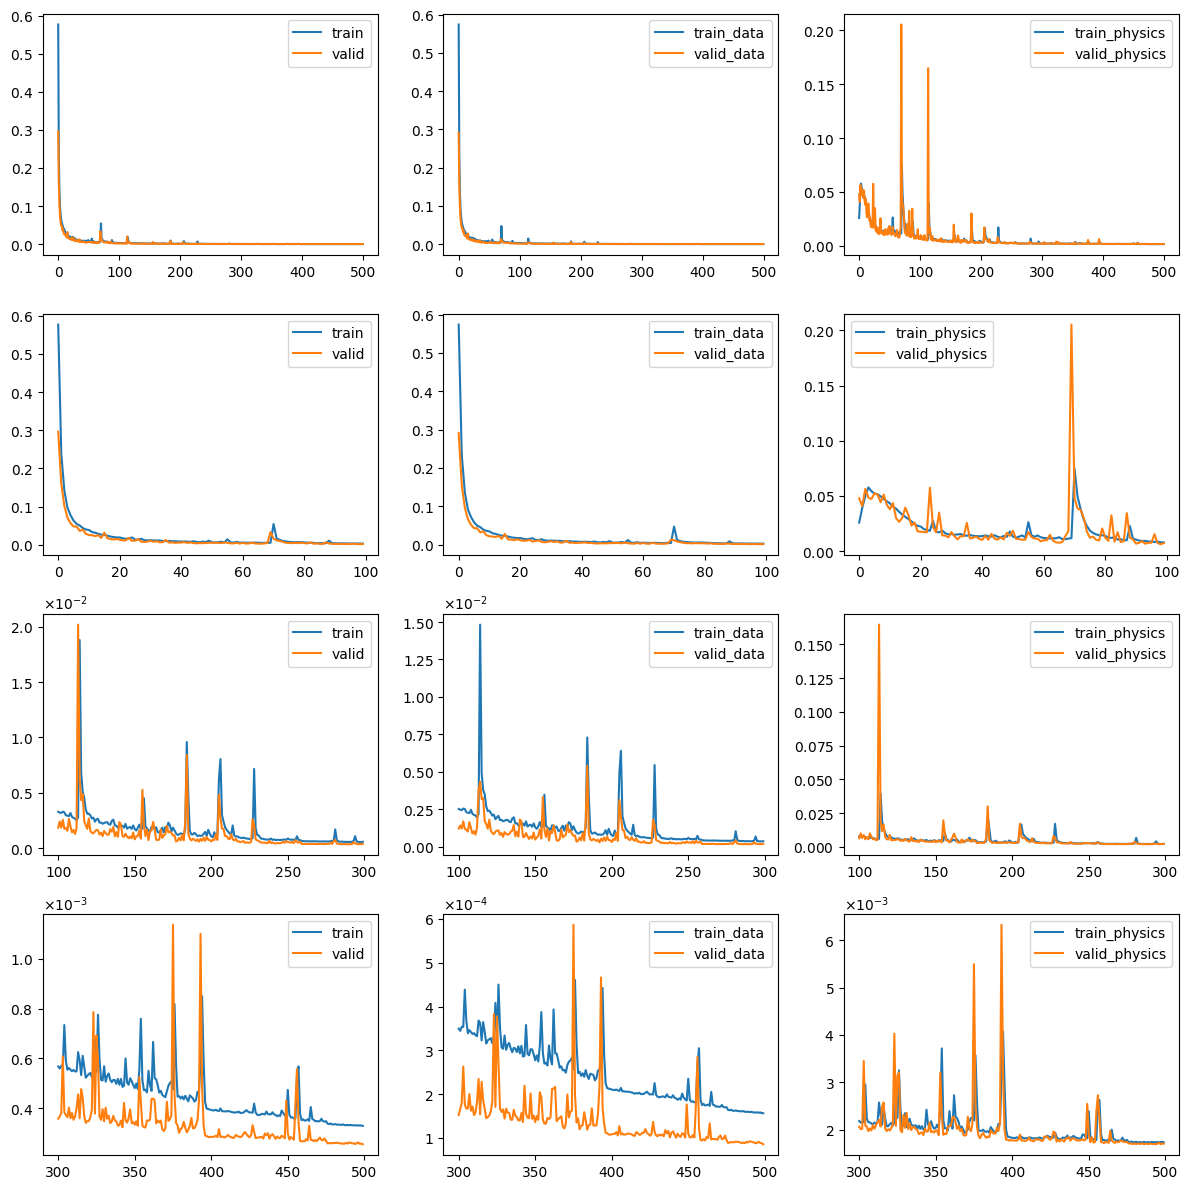

In [11]:
def plot(df, ax):
    for x in ax:
        x.ticklabel_format(axis='y', style='sci', scilimits=(-2,2), useMathText=True)

    df[["train", "valid"]].plot(ax=ax[0])
    df[["train_data", "valid_data"]].plot(ax=ax[1])
    df[["train_physics", "valid_physics"]].plot(ax=ax[2])
    
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(4, 3, figsize=(12, 12), tight_layout=True)

plot(history_df, ax[0])
plot(history_df[:100], ax[1])
plot(history_df[100:300], ax[2])
plot(history_df[300:], ax[3])

fig.savefig(run_dir / "losses.png")
history_df.to_csv(run_dir / "losess.csv")

In [20]:
# Učitaj originalne podatke za vizuelizaciju i evaluaciju
data_path = pathlib.Path("data")
file_name = "full_data_v2"

train_df_original, valid_df_original, test_df_original = load_data(data_path, file_name)


train_df_original = train_df_original.sort_values(
    ["re", "time", "y", "x"]
).reset_index(drop=True)

valid_df_original = valid_df_original.sort_values(
    ["re", "time", "y", "x"]
).reset_index(drop=True)

test_df_original = test_df_original.sort_values(
    ["re", "time", "y", "x"]
).reset_index(drop=True)

print(f"Train skup: {train_df_original.shape[0]} redova")
print(f"Valid skup: {valid_df_original.shape[0]} redova")
print(f"Test skup: {test_df_original.shape[0]} redova")
print(f"\nVremenske korake: {sorted(train_df_original['time'].unique().tolist())}")
print(f"Reynolds brojevi: {sorted(train_df_original['re'].unique().tolist())}")

Train skup: 1576960 redova
Valid skup: 315392 redova
Test skup: 1441792 redova

Vremenske korake: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
Reynolds brojevi: [100.0, 136.73469387755102, 155.10204081632654, 191.8367346938776, 210.20408163265307, 246.9387755102041, 265.30612244897964, 283.6734693877551, 338.7755102040817, 357.1428571428572, 375.5102040816327, 393.8775510204082, 412.2448979591837, 448.9795918367347, 485.7142857142858, 504.08163265306126, 540.8163265306123, 577.5510204081634, 595.9183673469388, 614.2857142857143, 632.6530612244899, 651.0204081632653, 687.7551020408164, 706.1224489795919, 724.4897959183675, 761.2244897959184, 779.591836734694, 797.9591836734694, 816.3265306122449, 834.6938775510205, 908.1632653061224, 944.8979591836736, 963.265306122449, 981.6326530612246, 1000.0]


## Vizuelizacija

Dostupni Reynolds brojevi: [118.36734693877553, 228.57142857142856, 320.40816326530614, 430.6122448979592, 559.1836734693878]... (ukupno 8)
Dostupni vremenski koraci: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]


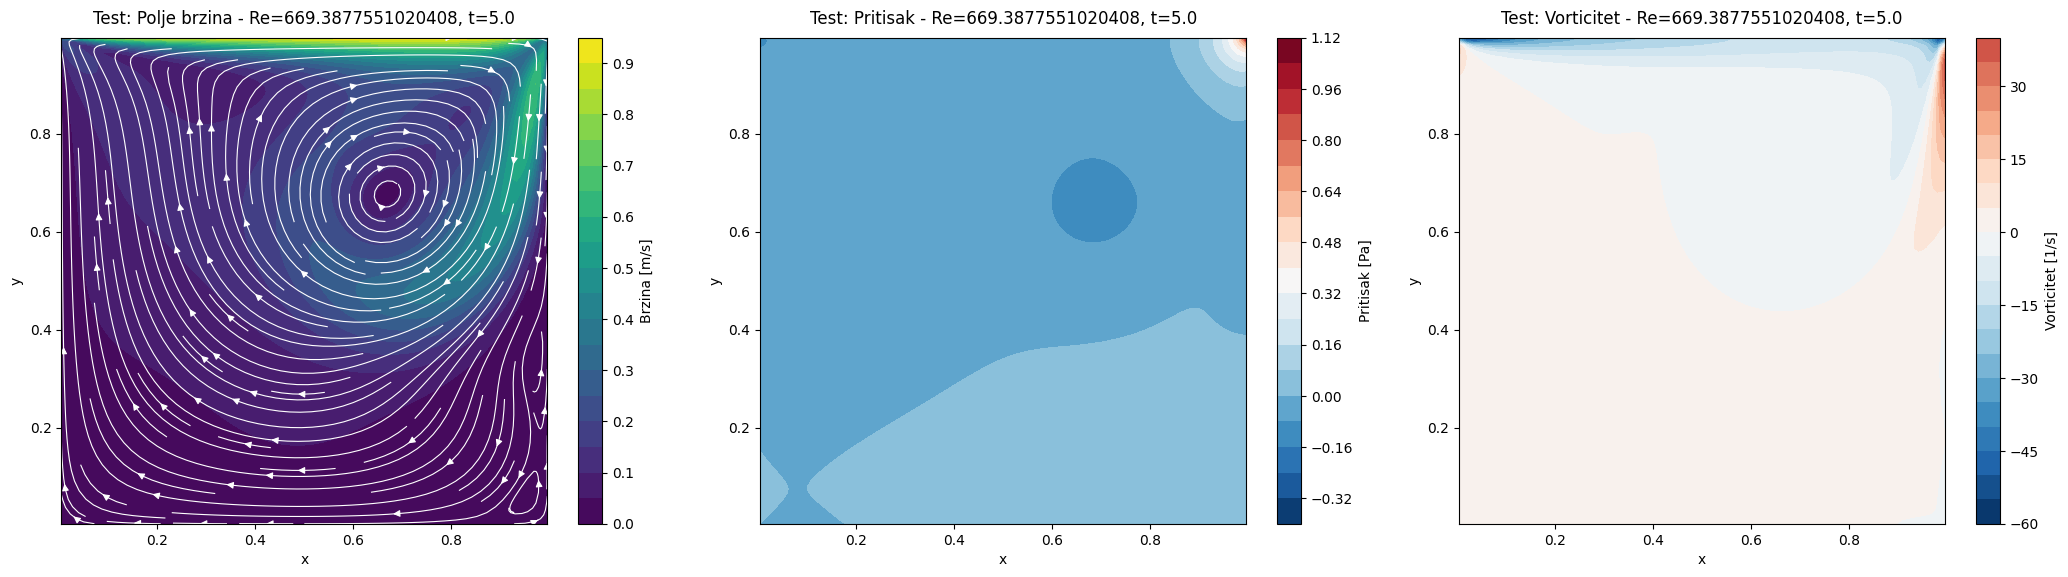

In [21]:
# Primjer: vizuelizacija test skupa
re_values = sorted(test_df_original['re'].unique().tolist())
time_steps = sorted(test_df_original['time'].unique().tolist())

print(f"Dostupni Reynolds brojevi: {re_values[:5]}... (ukupno {len(re_values)})")
print(f"Dostupni vremenski koraci: {time_steps}")

# Vizuelizacija jednog Rejnoldsovog broja u datom vremenskom trenutku
visual.plot_velocity_and_pressure(test_df_original, time_steps[5], re_values[5], "Test:")

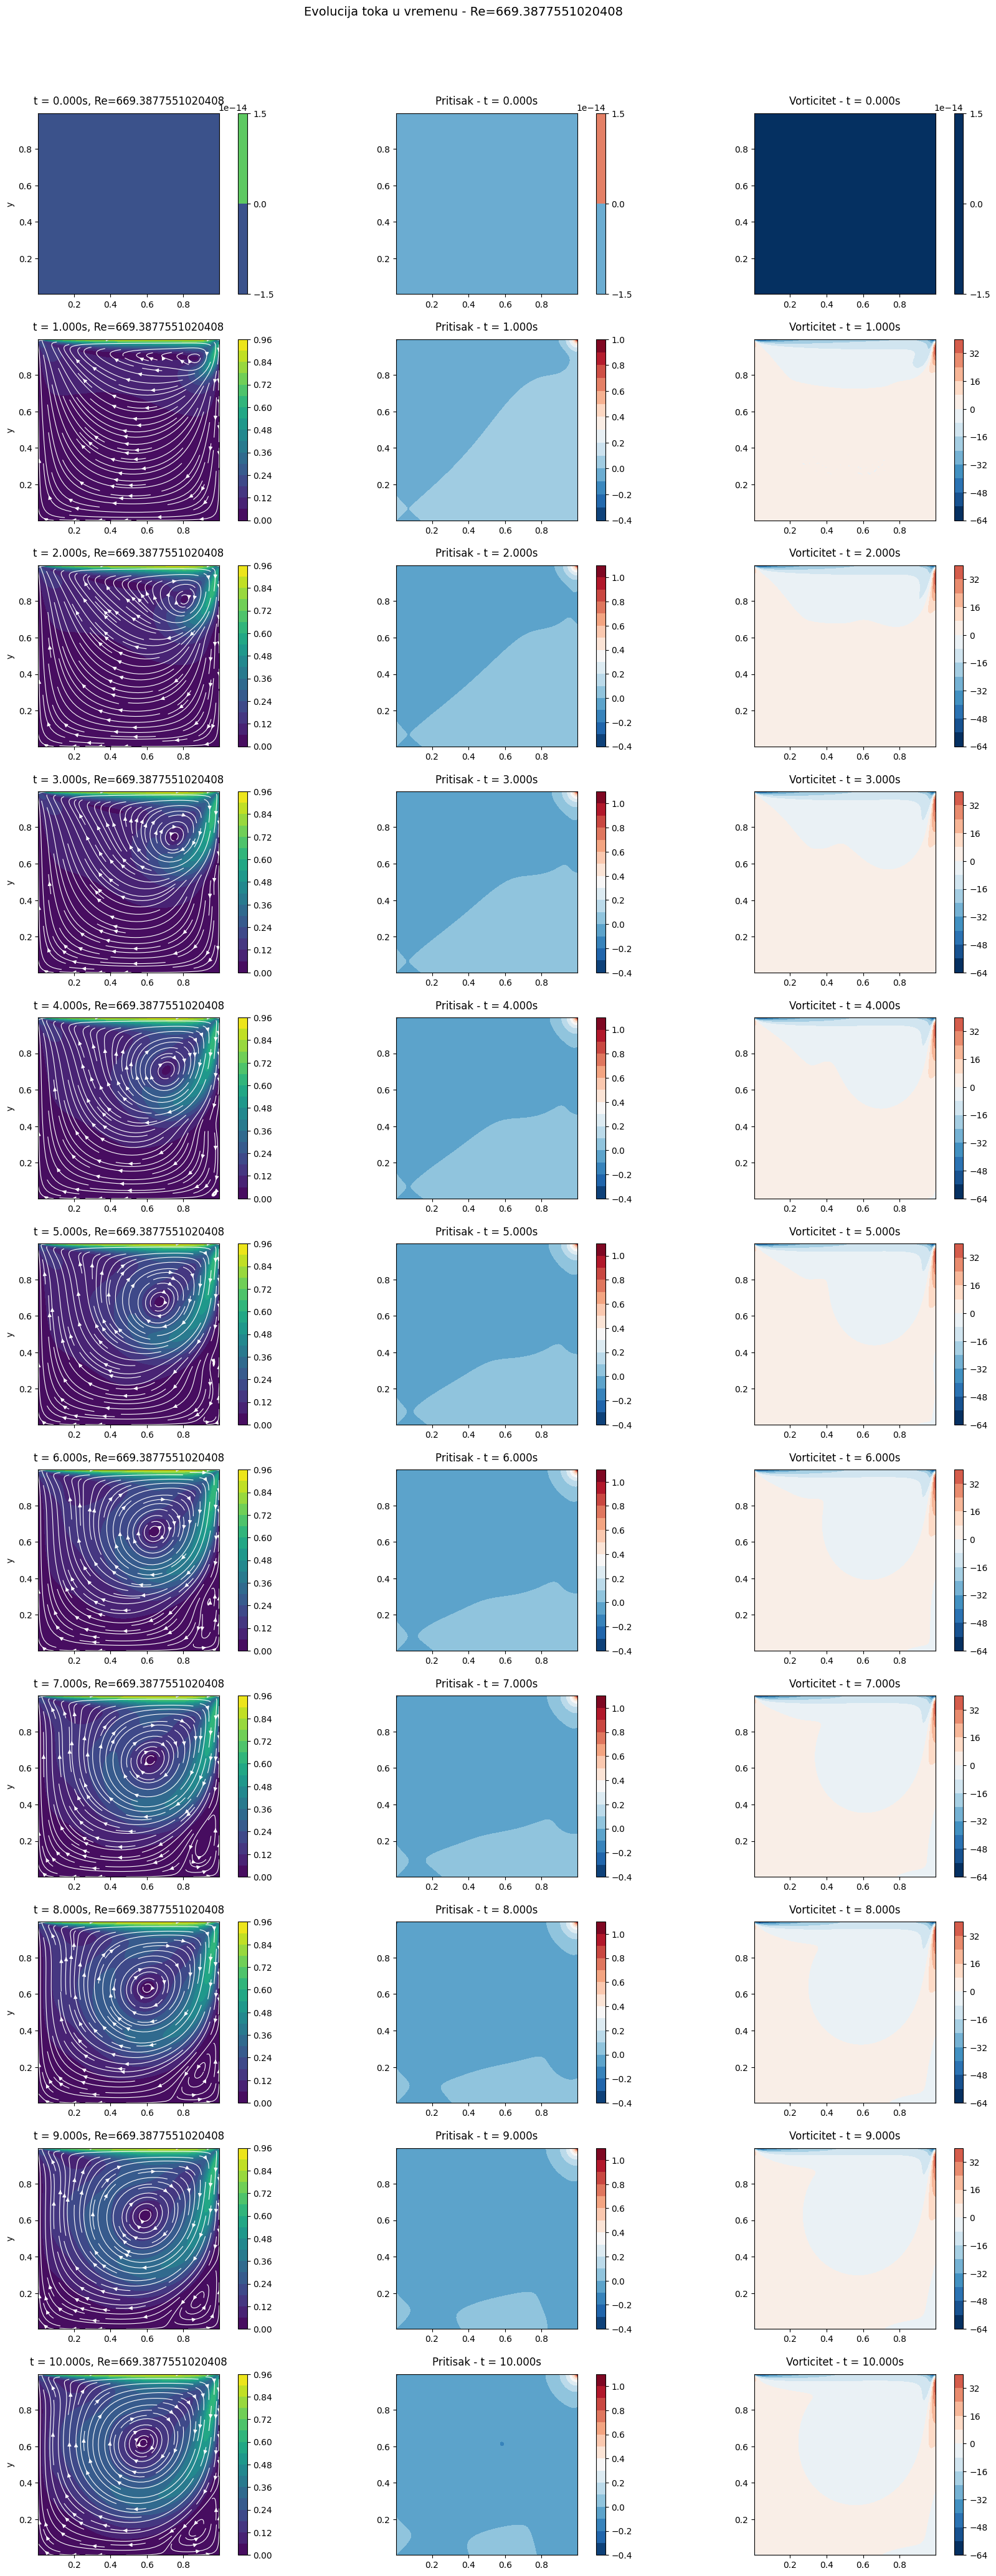

In [22]:
# Vizuelizacija evolucije kroz test skupa za jedan Rejnoldsov broj
visual.plot_evolution_in_time(test_df_original, re_values[5])

MAE U_x: 0.002996
MAE U_y: 0.002367
MAE p:   0.000800


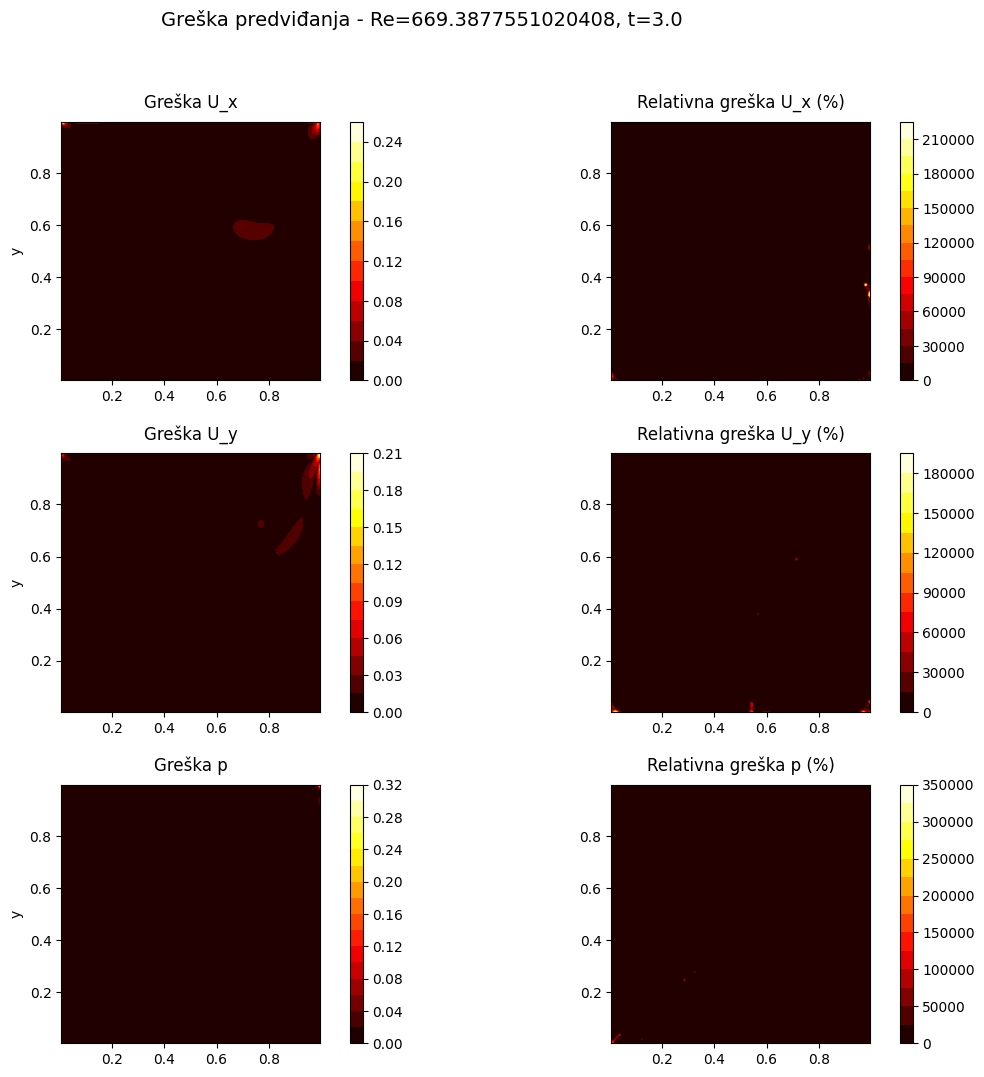

In [23]:
# Poređenje predviđanja modela sa stvarnim podacima
visual.compare_predictions(model, test_df_original, time_steps[3], re_values[5], mean, std, device)

In [24]:
visual.evaluate(model, test_df_original, mean, std, device, run_dir / "animations", 2)

Generiši 11 frame-ova greške...
  ✓ 2/11 frame-ova generisano
  ✓ 4/11 frame-ova generisano
  ✓ 6/11 frame-ova generisano
  ✓ 8/11 frame-ova generisano
  ✓ 10/11 frame-ova generisano

Kombinujem slike u GIF (runs/2026-07-09_14-27-55/animations/error_animation_Re_118.gif)...
✓ GIF greške spreman: runs/2026-07-09_14-27-55/animations/error_animation_Re_118.gif
Generiši 11 frame-ova greške...
  ✓ 2/11 frame-ova generisano
  ✓ 4/11 frame-ova generisano
  ✓ 6/11 frame-ova generisano
  ✓ 8/11 frame-ova generisano
  ✓ 10/11 frame-ova generisano

Kombinujem slike u GIF (runs/2026-07-09_14-27-55/animations/error_animation_Re_228.gif)...
✓ GIF greške spreman: runs/2026-07-09_14-27-55/animations/error_animation_Re_228.gif
Generiši 11 frame-ova greške...
  ✓ 2/11 frame-ova generisano
  ✓ 4/11 frame-ova generisano
  ✓ 6/11 frame-ova generisano
  ✓ 8/11 frame-ova generisano
  ✓ 10/11 frame-ova generisano

Kombinujem slike u GIF (runs/2026-07-09_14-27-55/animations/error_animation_Re_320.gif)...
✓ GIF

In [25]:
visual.animate_truth_vs_pred(model, test_df_original, re_values[5], 
                             mean, std, device, fps=2, 
                             output_file=run_dir / "animations" / "truth_vs_pred.gif")

Izračunavanje predikcija za 11 vremenskih koraka...
Renderovanje frejmova...
  ✓ 2/11 frejmova generisano
  ✓ 4/11 frejmova generisano
  ✓ 6/11 frejmova generisano
  ✓ 8/11 frejmova generisano
  ✓ 10/11 frejmova generisano
✓ GIF uspješno kreiran: runs/2026-07-09_14-27-55/animations/truth_vs_pred.gif


PosixPath('runs/2026-07-09_14-27-55/animations/truth_vs_pred.gif')

## Evaluacija

In [26]:
# Full evaluation summary for all splits

split_dfs = {
    "valid": valid_df_original,
    "test": test_df_original,
}

for split_name, split_df in split_dfs.items():
    print(f"\n{'=' * 60}")
    print(f"{split_name.upper()} EVALUATION")
    print(f"{'=' * 60}")

    data_metrics = utils.evaluate_model(
        model=model,
        df=split_df,
        input_col_names=input_col_names,
        target_col_names=target_col_names,
        mean=mean,
        std=std,
        device=device,
    )

    print(f"\nSamples: {len(split_df)}")
    print("\nSupervised metrics (original scale):")
    pprint(data_metrics)


VALID EVALUATION

Samples: 315392

Supervised metrics (original scale):
{'U_x': {'MAE': 0.0008796933078461857,
         'MSE': 2.8796994774874122e-06,
         'MaxAbsError': 0.060464948415756226,
         'R2': 0.9998939291024703,
         'RMSE': 0.0016969677302433928,
         'RelL2': 0.010299071856682522},
 'U_y': {'MAE': 0.000722426463105852,
         'MSE': 1.5594797813250375e-06,
         'MaxAbsError': 0.03412999212741852,
         'R2': 0.9998978847943134,
         'RMSE': 0.0012487913281749828,
         'RelL2': 0.010105206208105325},
 'all': {'MAE': 0.0005913169993915195,
         'MSE': 1.5056409678325098e-06,
         'MaxAbsError': 0.060464948415756226,
         'R2': 0.9998972748990468,
         'RMSE': 0.0012270456258153199,
         'RelL2': 0.010129709470047031},
 'p': {'MAE': 0.00017183122722252097,
       'MSE': 7.774364468507907e-08,
       'MaxAbsError': 0.010818779468536377,
       'R2': 0.9999463817783969,
       'RMSE': 0.0002788254735225587,
       'RelL2': 